# Levraging CNNs-Convolutional Nueral Network in Fashion MNIST Data

Convolutional Neural Networks (CNNs) are a type of deep learning model specifically designed to process and analyse structured data, such as images or videos. They are particularly effective in tasks like image classification, image recognition and object detection due to their ability to automatically and efficiently learn spatial hierarchies of features.

CNNs are generally used to improve the training and testing accuracy of the model which ANN is not able to do efficiently.

Here **CNNs are applied through PyTorch**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
df = pd.read_csv('/content/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(60000, 785)

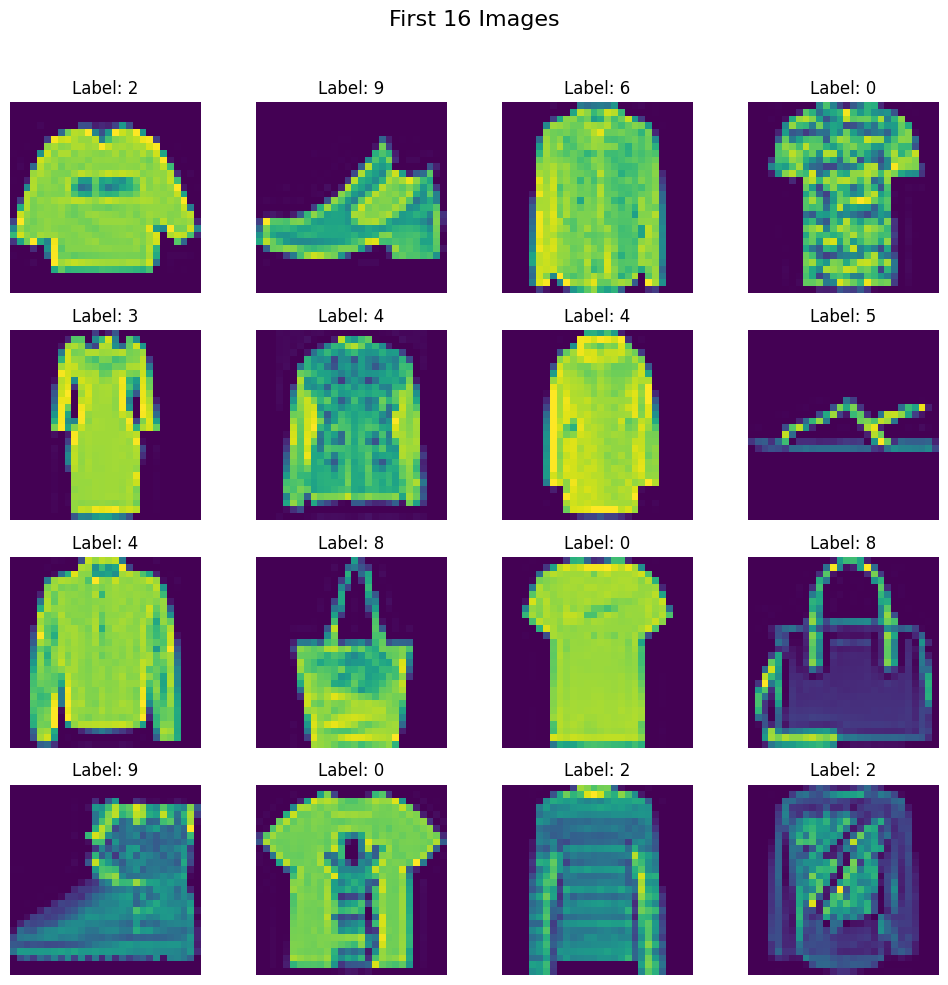

In [6]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [7]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train = X_train/255.0
X_test = X_test/255.0

In [10]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1, 1, 28, 28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [11]:
train_dataset = CustomDataset(X_train, y_train)

In [12]:
test_dataset = CustomDataset(X_test, y_test)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [14]:
class MyNN(nn.Module):

  def __init__(self, input_features):

    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.6),

        nn.Linear(64, 10)
    )



  def forward(self, x):

    x = self.features(x)
    x = self.classifier(x)

    return x

In [15]:
# # objective function
# def objective(trial):

#   # next hyperparameter values from the search space
#   num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
#   neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
#   epochs = trial.suggest_int("epochs", 10, 50, step=10)
#   learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
#   dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
#   batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
#   optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
#   weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

#   train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
#   test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

#   # model init
#   input_dim = 784
#   output_dim = 10

#   model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
#   model.to(device)

#   # optimizer selection
#   criterion = nn.CrossEntropyLoss()
#   optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

#   if optimizer_name == 'Adam':
#     optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
#   elif optimizer_name == 'SGD':
#     optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
#   else:
#     optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

#   # training loop

#   for epoch in range(epochs):

#     for batch_features, batch_labels in train_loader:

#       # move data to gpu
#       batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#       # forward pass
#       outputs = model(batch_features)

#       # calculate loss
#       loss = criterion(outputs, batch_labels)

#       # back pass
#       optimizer.zero_grad()
#       loss.backward()

#       # update grads
#       optimizer.step()


#   # evaluation
#   model.eval()
#   # evaluation on test data
#   total = 0
#   correct = 0

#   with torch.no_grad():

#     for batch_features, batch_labels in test_loader:

#       # move data to gpu
#       batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

#       outputs = model(batch_features)

#       _, predicted = torch.max(outputs, 1)

#       total = total + batch_labels.shape[0]

#       correct = correct + (predicted == batch_labels).sum().item()

#     accuracy = correct/total

#   return accuracy

In [16]:
learning_rate = 0.01
epochs = 100

In [17]:
model = MyNN(1)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [18]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.8582452552815278
Epoch: 2 , Loss: 0.5209688788453738
Epoch: 3 , Loss: 0.4471000665773948
Epoch: 4 , Loss: 0.4006745201945305
Epoch: 5 , Loss: 0.36883102563768627
Epoch: 6 , Loss: 0.34811117382844287
Epoch: 7 , Loss: 0.32736437653253475
Epoch: 8 , Loss: 0.30942598810543614
Epoch: 9 , Loss: 0.29484161525219676
Epoch: 10 , Loss: 0.2822894324262937
Epoch: 11 , Loss: 0.2690158517857393
Epoch: 12 , Loss: 0.25909957344581686
Epoch: 13 , Loss: 0.2485976063447694
Epoch: 14 , Loss: 0.24052408736012876
Epoch: 15 , Loss: 0.23252008721542855
Epoch: 16 , Loss: 0.22640607814056177
Epoch: 17 , Loss: 0.22039926404009264
Epoch: 18 , Loss: 0.21594624615398547
Epoch: 19 , Loss: 0.20106240170138578
Epoch: 20 , Loss: 0.20172391097340733
Epoch: 21 , Loss: 0.19127143782873948
Epoch: 22 , Loss: 0.19024320053247115
Epoch: 23 , Loss: 0.18468831644641856
Epoch: 24 , Loss: 0.17836491841108848
Epoch: 25 , Loss: 0.17250744887876013
Epoch: 26 , Loss: 0.1735382628530885
Epoch: 27 , Loss: 0.170031997

In [19]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.6, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

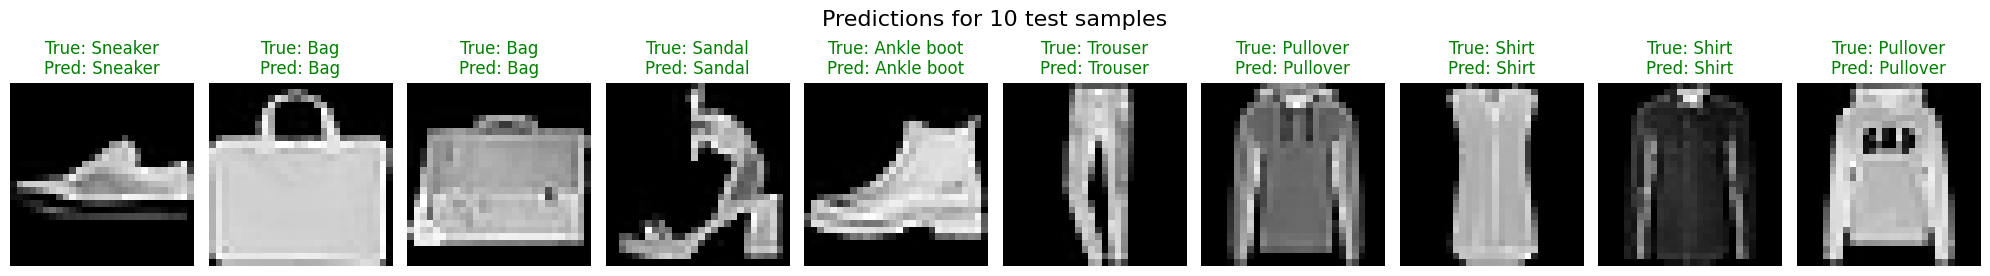

Visualized predictions for the first 10 test samples.


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

model.eval() # Set model to evaluation mode

# Get a batch of images and labels from the test_loader for visualization
# Let's visualize the first 10 samples from the test dataset.
num_samples_to_show = 10
fig, axes = plt.subplots(1, num_samples_to_show, figsize=(20, 3))

with torch.no_grad():
    for i in range(num_samples_to_show):
        image, true_label = test_dataset[i] # Get i-th sample from the test dataset
        # Add batch dimension (unsqueeze) and move to the appropriate device (CPU/GPU)
        image_processed = image.unsqueeze(0).to(device)

        # Get model output
        output = model(image_processed)
        # Get the predicted class index (highest probability)
        _, predicted_label_idx = torch.max(output, 1)
        predicted_label_idx = predicted_label_idx.item() # Convert tensor to Python int

        # Detach the image from GPU, remove batch dimension, reshape and convert to numpy for plotting
        image_np = image.cpu().squeeze().numpy() # Squeeze removes the channel dimension (1)

        ax = axes[i]
        ax.imshow(image_np, cmap='gray')
        ax.set_title(f"True: {class_names[true_label.item()]}\nPred: {class_names[predicted_label_idx]}",
                     color='green' if true_label.item() == predicted_label_idx else 'red')
        ax.axis('off')

plt.suptitle(f"Predictions for {num_samples_to_show} test samples", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print(f"Visualized predictions for the first {num_samples_to_show} test samples.")

In [21]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9255


In [22]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9975
